In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. DATA PREPROCESSING & AUGMENTATION (Task 01 & 02)
# Galaxies are rotationally invariant, so flips and rotations are essential.
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(), # Valid for space images
        transforms.RandomRotation(180),  # Valid for space images
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.v2.GaussianNoise(mean=0.0, sigma=0.02),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "harsh": transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.GaussianBlur(kernel_size=9, sigma=(2, 4)),
    transforms.v2.JPEG(quality=25),
    transforms.ToTensor(),
    transforms.v2.GaussianNoise(mean=0.0, sigma=0.05),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225])
])
}

data_dir = {'train': "raw/image_folders/train/galaxy10_train",
            'val': "raw/image_folders/valid/galaxy10_test"}
image_datasets = {x: datasets.ImageFolder(data_dir[x], data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True) for x in ['train', 'val']}
stress_dataset = datasets.ImageFolder(data_dir['val'], data_transforms['harsh'])
stress_loader = DataLoader(stress_dataset, batch_size=32, shuffle=False)

In [35]:
def build_galaxy_model(num_classes=10):
    # Using EfficientNet-B0 as the backbone
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    
    # Freeze early layers to preserve feature extraction
    for param in model.features[:6].parameters():
        param.requires_grad = False
        
    # Replace the classifier head
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(num_ftrs, num_classes)
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_galaxy_model(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [36]:
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return all_labels, all_preds

In [37]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [47]:
import copy
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best performing one
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()


    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# EXECUTE TRAINING
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)
model = train_model(model, criterion, optimizer, scheduler, num_epochs=5)

for param in model.features[-3:].parameters():
    param.requires_grad = True
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)

# Train for longer (e.g., 10-15 epochs)
model = train_model(model, criterion, optimizer, scheduler, num_epochs=15)

Epoch 0/4
----------
train Loss: 1.1647 Acc: 0.7058
val Loss: 1.2989 Acc: 0.6426

Epoch 1/4
----------
train Loss: 1.1619 Acc: 0.7041
val Loss: 1.3021 Acc: 0.6578

Epoch 2/4
----------
train Loss: 1.1416 Acc: 0.7167
val Loss: 1.2870 Acc: 0.6654

Epoch 3/4
----------
train Loss: 1.1272 Acc: 0.7228
val Loss: 1.2496 Acc: 0.6821

Epoch 4/4
----------
train Loss: 1.1030 Acc: 0.7296
val Loss: 1.2234 Acc: 0.6891

Best val Acc: 0.689121
Epoch 0/14
----------
train Loss: 1.0540 Acc: 0.7508
val Loss: 1.1587 Acc: 0.7151

Epoch 1/14
----------
train Loss: 1.0300 Acc: 0.7620
val Loss: 1.1631 Acc: 0.7103

Epoch 2/14
----------
train Loss: 1.0278 Acc: 0.7610
val Loss: 1.2028 Acc: 0.7018

Epoch 3/14
----------
train Loss: 1.0222 Acc: 0.7700
val Loss: 1.1872 Acc: 0.7060

Epoch 4/14
----------
train Loss: 1.0135 Acc: 0.7674
val Loss: 1.2097 Acc: 0.7117

Epoch 5/14
----------
train Loss: 1.0065 Acc: 0.7697
val Loss: 1.1908 Acc: 0.7258

Epoch 6/14
----------
train Loss: 1.0019 Acc: 0.7752
val Loss: 1.1851

                         precision    recall  f1-score   support

          Barred Spiral       0.50      0.40      0.45       401
     Cigar Round Smooth       0.52      0.48      0.50        64
            Distributed       0.40      0.29      0.34       211
     Edge-on with Bulge       0.74      0.71      0.73       391
  Edge-on without Bulge       0.72      0.85      0.78       289
In-between Round Smooth       0.61      0.75      0.67       438
                Merging       0.62      0.68      0.65       355
           Round Smooth       0.66      0.71      0.68       483
   Unbarred Loss Spiral       0.54      0.44      0.48       544
  Unbarred Tight Spiral       0.48      0.52      0.50       372

               accuracy                           0.60      3548
              macro avg       0.58      0.58      0.58      3548
           weighted avg       0.59      0.60      0.59      3548



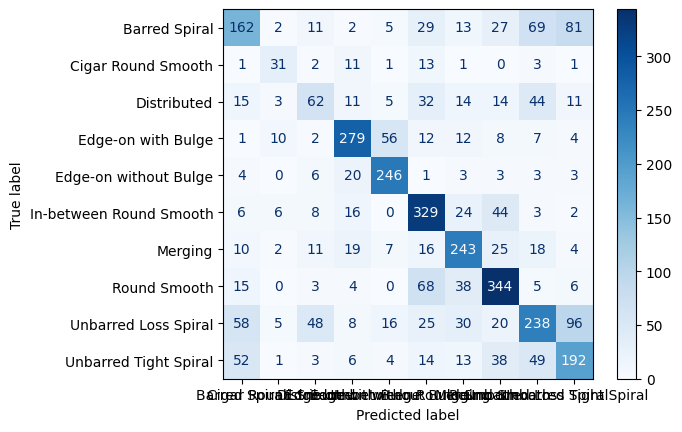

In [40]:
#final eval
#precision recall f1-score
import sklearn.metrics as metrics
all_labels = []
all_preds = []
target_names = ["Barred Spiral","Cigar Round Smooth","Distributed","Edge-on with Bulge","Edge-on without Bulge","In-between Round Smooth","Merging","Round Smooth","Unbarred Loss Spiral","Unbarred Tight Spiral"]
with torch.no_grad():
    for images, labels in dataloaders['val']:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
report = metrics.classification_report(all_labels, all_preds, target_names=target_names)
print(report)
#confusion matrix
import matplotlib.pyplot as plt
conf_matrix = metrics.confusion_matrix(all_labels, all_preds)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=target_names)
cm_display.plot(cmap=plt.cm.Blues)
plt.show()


In [46]:
#Stress test with harsh transforms
labels,preds = evaluate_model(model, stress_loader)
correct = (preds == labels).astype(int).sum().item()
total = labels.size(0)
acc = correct / total
print(f"Stress Test Accuracy: {acc:.4f}")